# Kienzle-Model CNC Simulation Pipeline — Synthetic Spindle-Current Generation

This notebook generates **synthetic spindle-motor-current signals** for every
parameter combination listed in `Experiment_sim.xlsx` (sheet `ANN 4240`),
using the Kienzle cutting-force model implemented in `kienzle_model.py`
(`KienzleModel`, `NoiseModel`) and the geometry helper in `kienzle_utils.py`
(`MillingSignalUtils`).

**Pipeline overview**

1. Load the 64 process-parameter combinations (`Ae`, `Ap`, `f`, `N`, `R`, `Z`, `fz`, `Vc`).
2. For each combination, derive the radial **entry angle** `phi_in` from the
   radial depth of cut `Ae` and the tool diameter `D = 2R`, holding the
   **exit angle fixed at `phi_out = 180°`** (down-milling convention; a full
   slot, `Ae = D`, yields `phi_in = 0°`, i.e. continuous engagement), via
   `MillingSignalUtils.entry_angle_from_ae`.
3. Build a time vector with `ts = 0.002 s` over `T = 8 s` (4000 samples).
4. Instantiate a `KienzleModel` per combination (spindle speed `omega` given
   directly in **rpm**, as in `Experiment_sim.xlsx`) and generate the
   **clean** torque/current signal `Mc_clean(t)`, `Iq_clean(t) = Mc_clean/km + I0`.
5. Add **Gamma-distributed noise** (run-to-run noise-level model: the
   Gaussian noise std `sigma_run` is itself drawn from a Gamma distribution,
   applied to the torque) to obtain the **noisy** signal `Iq(t)`.
6. Save `time`, `Iq_clean` (clean signal) and `Iq` (noisy signal) for every
   combination as an individual CSV file inside a `_sim/` folder, and write
   back an updated parameter table that records each simulation's filename.

**Units convention:** lengths in mm, `kc1.1` in N/mm^2, torque `Mc` in N·mm,
spindle speed `omega` in rpm, `km` in N·mm/A, `I0` and `Iq(t)` in A.


## 1. Imports & data loading

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("..\py\src")
from kienzle_model import KienzleModel, NoiseModel
from kienzle_utils import MillingSignalUtils as MSU

# ---------------------------------------------------------------
# Load process-parameter table
# ---------------------------------------------------------------
EXCEL_PATH = "Experiment_sim.xlsx"
SHEET_NAME = "ANN 4240"

params = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
print(f"Loaded {len(params)} parameter combinations from '{EXCEL_PATH}' ({SHEET_NAME})")
params.head()

Loaded 64 parameter combinations from 'Experiment_sim.xlsx' (ANN 4240)


,Ae (mm),Ap (mm),f (mm/min),N (rpm),R (mm),Z,fz,Vc,sim_file
0,40,1.0,632.00,2108.0,20,2,0.149905,264.899093,NaN
1,38,1.0,632.00,2108.0,20,2,0.149905,264.899093,NaN
2,32,1.0,632.00,2108.0,20,2,0.149905,264.899093,NaN
3,26,1.0,632.00,2108.0,20,2,0.149905,264.899093,NaN
4,40,1.0,505.92,1686.4,20,2,0.150000,211.919274,NaN


## 2. Radial engagement geometry: entry angle from $a_e$

For peripheral (down-)milling, the radial engagement (immersion) angle is

$$
\varphi_{\text{eng}} = \arccos\!\left(1 - \frac{2 a_e}{D}\right), \qquad D = 2R
$$

With the **exit angle fixed at $\varphi_{\text{out}} = 180°$**, the entry angle is

$$
\varphi_{\text{in}} = \varphi_{\text{out}} - \varphi_{\text{eng}}
$$

so that a full slot ($a_e = D$) gives $\varphi_{\text{eng}} = 180°$ and
$\varphi_{\text{in}} = 0°$ (continuous tooth engagement), while a lighter
radial cut ($a_e < D$) yields $\varphi_{\text{in}} > 0°$, i.e. an
intermittent, tooth-passing torque signal.

Both quantities are computed with `MillingSignalUtils.engagement_angle_from_ae`
and `MillingSignalUtils.entry_angle_from_ae`.


In [14]:
D_tool = 2 * params["R (mm)"]                       # tool diameter [mm]
PHI_OUT = np.pi                                      # fixed exit angle = 180 deg

params["phi_eng_deg"] = np.degrees(
    [MSU.engagement_angle_from_ae(ae, D) for ae, D in zip(params["Ae (mm)"], D_tool)]
)
params["phi_out_deg"] = np.degrees(PHI_OUT)
params["phi_in_deg"] = np.degrees(
    [MSU.entry_angle_from_ae(ae, D, phi_out=PHI_OUT) for ae, D in zip(params["Ae (mm)"], D_tool)]
)

params[["Ae (mm)", "R (mm)", "phi_eng_deg", "phi_in_deg", "phi_out_deg"]].drop_duplicates(
    subset=["Ae (mm)", "R (mm)"]
).reset_index(drop=True)

,Ae (mm),R (mm),phi_eng_deg,phi_in_deg,phi_out_deg
0,40,20,180.000000,0.000000,180.0
1,38,20,154.158067,25.841933,180.0
2,32,20,126.869898,53.130102,180.0
3,26,20,107.457603,72.542397,180.0


## 3. Simulation constants

In [15]:
# ---------------------------------------------------------------
# Kienzle material constants (4240 material, ST45-like defaults)
# ---------------------------------------------------------------
KC11 = 1#1633.0     # specific cutting force coefficient kc1.1 [N/mm^2]
MC   = 0.23       # Kienzle exponent mc [-]

# ---------------------------------------------------------------
# Motor / current-conversion constants
# ---------------------------------------------------------------
KM = 1#1.3          # motor torque constant [N*mm / A]
I0 = 1.8          # no-load current offset [A]

# ---------------------------------------------------------------
# Tool / cutting-edge geometry
# ---------------------------------------------------------------
KAPPA_DEG = 90.0  # cutting-edge (lead) angle [deg]
PHI0_DEG  = 0.0   # phase offset of tooth 0 [deg]

# ---------------------------------------------------------------
# Sampling
# ---------------------------------------------------------------
TS = 0.0001        # sample time [s]
T_TOTAL = 4.0     # total simulation time [s]
TIME = np.arange(0, T_TOTAL, TS)
N_SAMPLES = len(TIME)
print(f"ts = {TS} s, T = {T_TOTAL} s -> {N_SAMPLES} samples per signal")

# ---------------------------------------------------------------
# Gamma-distributed noise-level model
#   sigma_run ~ Gamma(shape, scale) + loc   (units: N*mm)
#   -> applied as the std of an additive zero-mean Gaussian on Mc(t)
# ---------------------------------------------------------------
GAMMA_SHAPE = 161.763
GAMMA_SCALE = 0.001242
GAMMA_LOC   = 0.0
print(f"Gamma noise level: E[sigma] = {GAMMA_SHAPE*GAMMA_SCALE + GAMMA_LOC:.4f} N*mm "
      f"(shape={GAMMA_SHAPE}, scale={GAMMA_SCALE}, loc={GAMMA_LOC})")

# Output folder for per-combination simulation CSVs
SIM_DIR = "_sim"
os.makedirs(SIM_DIR, exist_ok=True)

ts = 0.0001 s, T = 4.0 s -> 40000 samples per signal
Gamma noise level: E[sigma] = 0.2009 N*mm (shape=161.763, scale=0.001242, loc=0.0)


## 4. Simulation loop

For each parameter combination:

1. Build the `KienzleModel` using `phi_in`/`phi_out` from Step 2 (radians),
   the process parameters (`ap`, `fz`, `N` in rpm, `z`, `r_tool = R`), the
   material constants from Step 3, and a **combination-specific seed** for
   reproducible-yet-distinct Gamma noise draws.
2. Generate the clean/noisy torque (`Mc_clean`, `Mc`) and current
   (`Iq_clean`, `Iq`) via `model.to_dataframe()`.
3. Save `time`, the **clean signal** (`Iq_clean`) and the **noisy signal**
   (`Iq`), both in A, to `_sim/<sim_file>.csv`.
4. Record the filename, the realized noise std (`sigma_run`), and the
   resulting SNR back into the parameter table.


In [16]:
sim_files   = []
sigma_runs  = []
snr_db_list = []

for idx, row in params.iterrows():
    ae   = row["Ae (mm)"]
    ap   = row["Ap (mm)"]
    R    = row["R (mm)"]
    Z    = int(row["Z"])
    fz   = row["fz"]
    N_rpm = row["N (rpm)"]

    phi_in  = np.radians(row["phi_in_deg"])
    phi_out = np.radians(row["phi_out_deg"])

    model = KienzleModel(
        mc=MC, kc11=KC11,
        phi_in=phi_in, phi_out=phi_out,
        fz=fz, ap=ap, omega=N_rpm, time=TIME, z=Z,
        r_tool=R, kappa_deg=KAPPA_DEG, phi0_deg=PHI0_DEG,
        km=KM, I0=I0,
        gamma_shape=GAMMA_SHAPE, gamma_scale=GAMMA_SCALE, gamma_loc=GAMMA_LOC,
        seed=1000 + idx,
    )

    df_sim = model.to_dataframe()

    # filename encodes the key process parameters
    fname = (
        f"sim_{idx:03d}_ae{ae:g}_ap{ap:g}_N{N_rpm:.1f}_fz{fz:.4f}.csv"
    )
    out_path = os.path.join(SIM_DIR, fname)

    df_sim[["time", "Iq_clean", "Iq"]].rename(
        columns={"Iq_clean": "signal_clean", "Iq": "signal_noisy"}
    ).to_csv(out_path, index=False)

    sim_files.append(fname)
    sigma_runs.append(model.last_sigma_no_load)
    snr_db_list.append(model.snr_db())

params["sim_file"]  = sim_files
params["sigma_run_Nmm"] = sigma_runs
params["snr_db"]    = snr_db_list

print(f"Saved {len(sim_files)} simulation files to '{SIM_DIR}/'")
params[["Ae (mm)", "Ap (mm)", "N (rpm)", "fz", "sim_file", "sigma_run_Nmm", "snr_db"]].head(8)

Saved 64 simulation files to '_sim/'


,Ae (mm),Ap (mm),N (rpm),fz,sim_file,sigma_run_Nmm,snr_db
0,40,1.0,2108.0,0.149905,sim_000_ae40_ap1_N2108.0_fz0.1499.csv,0.195468,16.256530
1,38,1.0,2108.0,0.149905,sim_001_ae38_ap1_N2108.0_fz0.1499.csv,0.215571,18.081727
2,32,1.0,2108.0,0.149905,sim_002_ae32_ap1_N2108.0_fz0.1499.csv,0.202189,19.573771
3,26,1.0,2108.0,0.149905,sim_003_ae26_ap1_N2108.0_fz0.1499.csv,0.184801,19.731759
4,40,1.0,1686.4,0.150000,sim_004_ae40_ap1_N1686.4_fz0.1500.csv,0.200711,16.255264
5,38,1.0,1686.4,0.150000,sim_005_ae38_ap1_N1686.4_fz0.1500.csv,0.189482,18.083494
6,32,1.0,1686.4,0.150000,sim_006_ae32_ap1_N1686.4_fz0.1500.csv,0.219514,19.578987
7,26,1.0,1686.4,0.150000,sim_007_ae26_ap1_N1686.4_fz0.1500.csv,0.184008,19.738158


## 5. Save updated parameter table

In [17]:
params_out_path = "Experiment_sim_with_sim_files.csv"
params.to_csv(params_out_path, index=False)
print(f"Updated parameter table written to '{params_out_path}'")
params.head()

Updated parameter table written to 'Experiment_sim_with_sim_files.csv'


,Ae (mm),Ap (mm),f (mm/min),N (rpm),R (mm),Z,fz,Vc,sim_file,phi_eng_deg,phi_out_deg,phi_in_deg,sigma_run_Nmm,snr_db
0,40,1.0,632.00,2108.0,20,2,0.149905,264.899093,sim_000_ae40_ap1_N2108.0_fz0.1499.csv,180.000000,180.0,0.000000,0.195468,16.256530
1,38,1.0,632.00,2108.0,20,2,0.149905,264.899093,sim_001_ae38_ap1_N2108.0_fz0.1499.csv,154.158067,180.0,25.841933,0.215571,18.081727
2,32,1.0,632.00,2108.0,20,2,0.149905,264.899093,sim_002_ae32_ap1_N2108.0_fz0.1499.csv,126.869898,180.0,53.130102,0.202189,19.573771
3,26,1.0,632.00,2108.0,20,2,0.149905,264.899093,sim_003_ae26_ap1_N2108.0_fz0.1499.csv,107.457603,180.0,72.542397,0.184801,19.731759
4,40,1.0,505.92,1686.4,20,2,0.150000,211.919274,sim_004_ae40_ap1_N1686.4_fz0.1500.csv,180.000000,180.0,0.000000,0.200711,16.255264


## 6. Sanity-check plots

Below: the clean vs. noisy current signal for a **full-slot** combination
($a_e = 40$ mm $= D$, continuous engagement, $\varphi_{in}=0°$) and a
**light radial cut** combination ($a_e = 26$ mm, intermittent
tooth-passing engagement, $\varphi_{in} \approx 72.5°$).


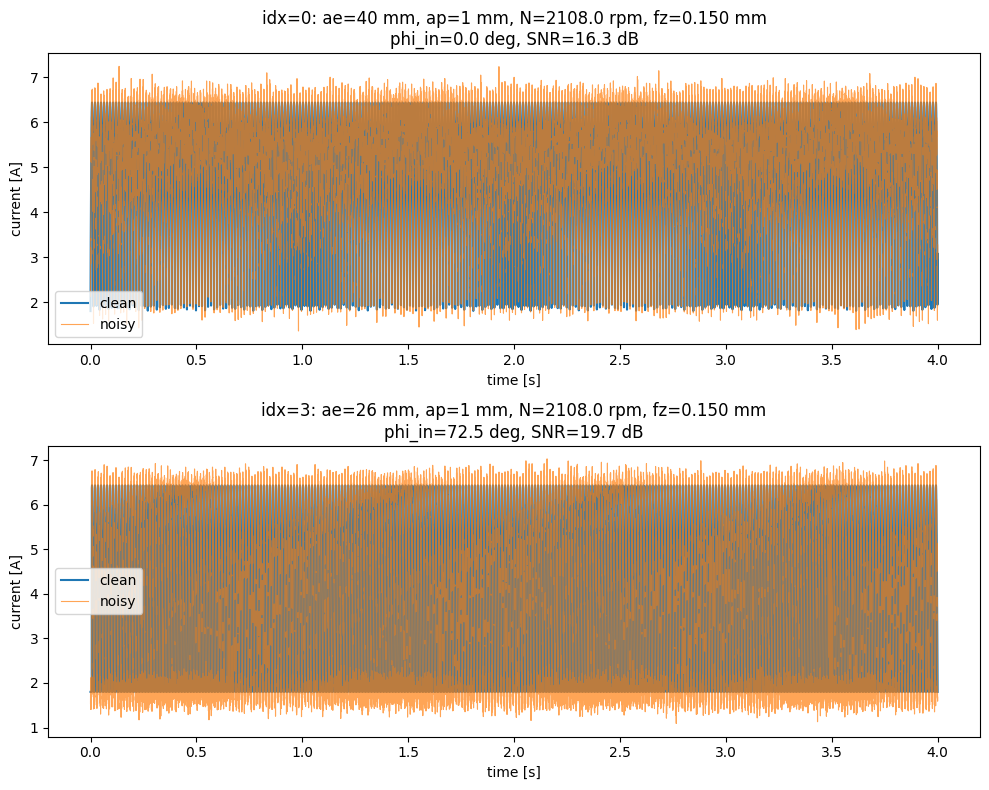

In [20]:
def plot_combo(idx, ax, n_show=100000):
    row = params.iloc[idx]
    df_sim = pd.read_csv(os.path.join(SIM_DIR, row["sim_file"]))
    t = df_sim["time"].values[:n_show]
    ax.plot(t, df_sim["signal_clean"].values[:n_show], label="clean", lw=1.5)
    ax.plot(t, df_sim["signal_noisy"].values[:n_show], label="noisy", lw=0.8, alpha=0.7)
    ax.set_title(
        f"idx={idx}: ae={row['Ae (mm)']:g} mm, ap={row['Ap (mm)']:g} mm, "
        f"N={row['N (rpm)']:.1f} rpm, fz={row['fz']:.3f} mm\n"
        f"phi_in={row['phi_in_deg']:.1f} deg, SNR={row['snr_db']:.1f} dB"
    )
    ax.set_xlabel("time [s]")
    ax.set_ylabel("current [A]")
    ax.legend()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

idx_slot  = params.index[(params["Ae (mm)"] == 40)][0]   # full slot
idx_light = params.index[(params["Ae (mm)"] == 26)][0]   # light radial cut

plot_combo(idx_slot, axes[0])
plot_combo(idx_light, axes[1])

plt.tight_layout()
plt.show()

## 7. Summary

- **64 parameter combinations** processed from `Experiment_sim.xlsx`.
- For each, `phi_in` was derived from `Ae`/`D` via
  `MillingSignalUtils.entry_angle_from_ae`, with `phi_out = 180°` fixed
  (down-milling convention).
- A `KienzleModel` instance (spindle speed given directly in rpm) generated
  the clean torque $M_c(t)$ and converted it to a simulated current
  $I_q(t) = M_c(t)/k_m + I_0$ using $k_{c1.1}=1633\ \text{N/mm}^2$,
  $m_c=0.23$, $k_m=1.3\ \text{N·mm/A}$, $I_0=1.8\ \text{A}$.
- A **Gamma-distributed noise-level model**
  ($\sigma_{\text{run}} \sim \Gamma(161.763,\ 0.001242)$, applied as the std
  of a zero-mean Gaussian on $M_c(t)$) produced the noisy signal — each
  combination uses a distinct seed (`1000 + idx`) so every CSV has its own
  realized $\sigma_{\text{run}}$ and SNR, both recorded in the updated
  parameter table.
- Outputs:
  - `_sim/sim_<idx>_ae<Ae>_ap<Ap>_N<N>_fz<fz>.csv` — `time`, `signal_clean`,
    `signal_noisy` (current in A), one file per combination (4000 rows each).
  - `Experiment_sim_with_sim_files.csv` — original parameter table plus
    `phi_in_deg`, `phi_out_deg`, `phi_eng_deg`, `sim_file`, `sigma_run_Nmm`,
    `snr_db`.

**Next steps:** the `_sim/*.csv` signals can be fed directly into the
existing feature-extraction / MLP pipeline (`ae_estimation_ann.ipynb`) as the
spindle-current time series for `ae` estimation.
